# Load and compare wet mode analysis

Analysis log

## Testing the consequence on the beam case from Alba (2025) paper

In [11]:
using Pkg
Pkg.activate("/home/shagun/Acads/HydroElasticFEM.jl")

using HydroElasticFEM

PKG_ROOT = HydroElasticFEM.PKG_ROOT

  Activating project at `~/Acads/HydroElasticFEM.jl`


"/home/shagun/Acads/HydroElasticFEM.jl/"

In [12]:
using JLD2
using Printf
using DataFrames
using Plots

In [13]:
fileName = "data/sims_202601/modes_beam_LRHS/"
# fileName = fileName*"beam_m=192.96_EI=333350.00/beam_modesdata.jld2"
fileName = fileName*"beam_m=192.96_EI=333350.00/lrhs_complexMass_free_resnM=385.91_resnK=385.91_modesdata.jld2"
df1 = load(PKG_ROOT*fileName)


@printf("Dry Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df1["dfDry"][:,"ωn"])
println()

@printf("Wet Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df1["dfWet"][:,"ωn"])
println()

nothing

Dry Natural Frequencies :
0.0005 + 0.0000im
0.0007 + 0.0000im
1.0306 + 0.0000im


┌ Warning: type Main.Beam_LRHS_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


2.3640 + 0.0000im
6.4085 + 0.0000im
12.5713 + 0.0000im

Wet Natural Frequencies :
0.6762 + -0.4273im
0.9969 + -0.0016im
1.4845 + -0.3177im
2.0024 + -0.3209im
3.0452 + -0.3250im
5.1673 + -0.2685im



In [14]:
fileName = "data/sims_202601/modes_beam_LRHS/"
fileName = fileName*"beam_m=192.96_EI=333350.00/lrhs_complexMass_free_resnM=385.91_resnK=385.91_modesdata.jld2"
df2 = load(PKG_ROOT*fileName)

@printf("Dry Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df2["dfDry"][:,"ωn"])
println()

@printf("Wet Natural Frequencies :\n")
(x -> @printf("%.4f + %.4fim\n", real(x), imag(x))).(df2["dfWet"][:,"ωn"])
println()

nothing

Dry Natural Frequencies :
0.0005 + 0.0000im


┌ Warning: type Main.Beam_LRHS_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


0.0007 + 0.0000im
1.0306 + 0.0000im
2.3640 + 0.0000im
6.4085 + 0.0000im
12.5713 + 0.0000im

Wet Natural Frequencies :
0.6762 + -0.4273im
0.9969 + -0.0016im
1.4845 + -0.3177im
2.0024 + -0.3209im
3.0452 + -0.3250im
5.1673 + -0.2685im



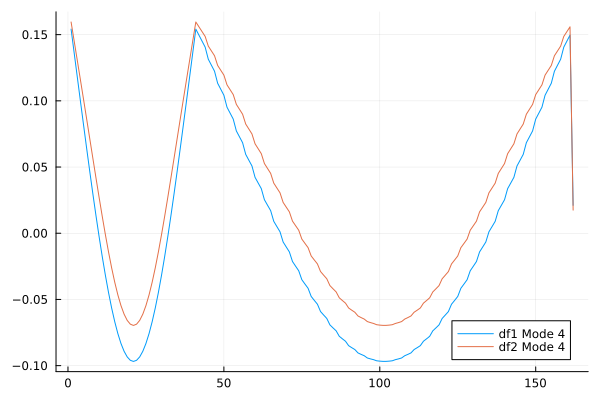

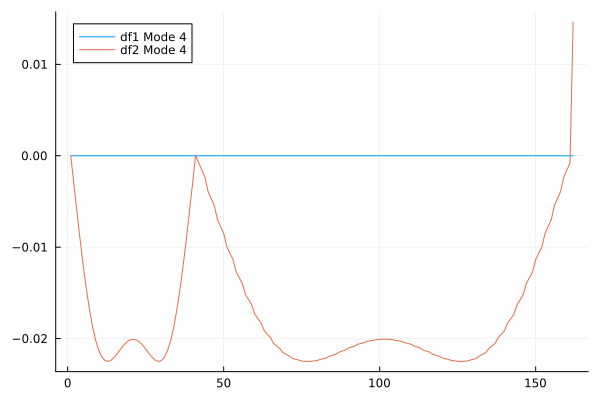

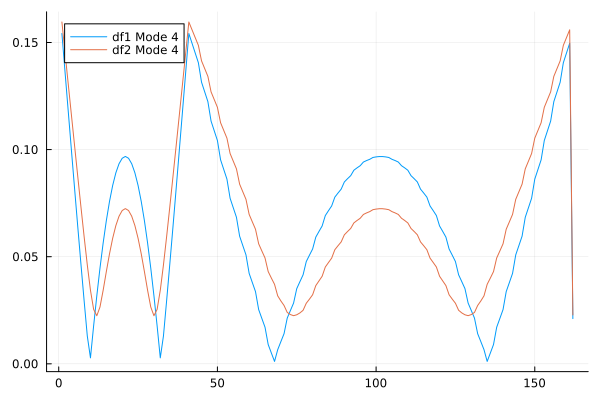

In [22]:
mode = 4
modeB = 4

df1_V = df1["dfDry"][:,"V"][mode]
df1_V = df1_V ./ sign(real(df1_V[1]))
df2_V = df2["dfWet"][:,"V"][modeB]
df2_V = df2_V ./ sign(real(df2_V[1]))


plot()
plot!(real(df1_V), label="df1 Mode $mode")
plot!(real(df2_V), label="df2 Mode $mode")
display(plot!())

plot()
plot!(imag(df1_V), label="df1 Mode $mode")
plot!(imag(df2_V), label="df2 Mode $mode")
display(plot!())

plot()
plot!(abs.(df1_V), label="df1 Mode $mode")
plot!(abs.(df2_V), label="df2 Mode $mode")
display(plot!())
